In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import os
from tqdm.auto import tqdm
import re
from pathlib import Path
import glob

In [5]:
import matplotlib.font_manager as fm
# ============================================================
# Fonts / style
# ============================================================
font_paths = [
    "/home/gzu5140/Font/Arial.ttf",
    "/home/gzu5140/Font/Arial Bold.ttf",
    "/home/gzu5140/Font/Arial Italic.ttf",
    "/home/gzu5140/Font/Arial Bold Italic.ttf",
]

for fp in font_paths:
    try:
        fm.fontManager.addfont(fp)
        print("✔ Loaded font:", fp)
    except Exception as e:
        print("⚠️  Could not load:", fp, "|", e)
# ==== LaTeX  ====
import matplotlib.pyplot as plt
plt.rcParams['pdf.fonttype'] = 42  # For PDF export
plt.rcParams['ps.fonttype'] = 42   # For PostScript (EPS) export
plt.rcParams['font.sans-serif'] = ["Arial"]
plt.rcParams['font.family'] = "sans-serif"
plt.rcParams['svg.fonttype'] = "none"
plt.rcParams['mathtext.fontset'] = "cm"
plt.rcParams['axes.labelsize'] = 18*1.5      # x/y labels
plt.rcParams['axes.titlesize'] = 20*1.5 
plt.rcParams['xtick.labelsize'] = 12*1.5     # x-axis tick labels
plt.rcParams['ytick.labelsize'] = 12*1.5    # y-axis tick labels
plt.rcParams['legend.fontsize'] = 12*1.5     # legend text

✔ Loaded font: /home/gzu5140/Font/Arial.ttf
✔ Loaded font: /home/gzu5140/Font/Arial Bold.ttf
✔ Loaded font: /home/gzu5140/Font/Arial Italic.ttf
✔ Loaded font: /home/gzu5140/Font/Arial Bold Italic.ttf


In [ ]:
path_to_plot_data = "/home/keerthm/twinfer/supp_figure/"
path_to_plots = "/home/keerthm/twinfer/plots_2/"
path_to_code_repo = "/home/keerthm/twinfer/TwINFER/"

import os
os.makedirs(path_to_plots, exist_ok=True)

# Effect of varying Hill constant

In [ ]:
plt.rcParams['axes.labelsize'] = 18*1.5*0.9     # x/y labels
plt.rcParams['axes.titlesize'] = 20*1.5*0.9  
plt.rcParams['xtick.labelsize'] = 12*1.5*0.9        # x-axis tick labels
plt.rcParams['ytick.labelsize'] = 12*1.5*0.9        # y-axis tick labels
plt.rcParams['legend.fontsize'] = 12*1.5*0.9        # legend text

In [ ]:
results = pd.read_csv(f"{path_to_plot_data}/effect_K.csv")
agg = (
    results.groupby("k")[["corr_t1", "corr_t2"]]
    .agg(["mean", "std"])
)

# flatten multiindex columns
agg.columns = ["_".join(col) for col in agg.columns]
agg = agg.reset_index()

# Plot
plt.figure(figsize=(6,4))

for corr in ["t1"]:
    mean = agg[f"corr_{corr}_mean"]
    std  = agg[f"corr_{corr}_std"]
    
    # mean line
    plt.plot(agg["k"], mean, marker = "o")
    # shaded std
    plt.fill_between(
        agg["k"], mean - std, mean + std, alpha=0.3
    )

# reference lines
plt.axvline(x=1, linestyle="--", color="red")
plt.axhline(y=0.0, linestyle="--", color="gray")

# Turn off clipping globally
for artist in plt.gcf().findobj():
    if hasattr(artist, "set_clip_on"):
        artist.set_clip_on(False)
# labels
plt.xlabel(r'$\frac{\mathrm{K}}{\left\langle \mathrm{TF} \right\rangle}$')
plt.ylabel(r'gene correlation $\rho$')
plt.tight_layout()

plt.savefig(
    f"{path_to_plots}/effect_Hill_constant.svg",
    format="svg",
    bbox_inches="tight",
    facecolor="none",    # transparent figure background
    edgecolor="none",
    transparent=True
)
plt.savefig(
    f"{path_to_plots}/effect_Hill_constant.png",
    format="png",
    bbox_inches="tight",
    facecolor="none",    # transparent figure background
    edgecolor="none",
    transparent=True
)
plt.savefig(
    f"{path_to_plots}/effect_Hill_constant.pdf",
    format="pdf",
    bbox_inches="tight",
    facecolor="none",    # transparent figure background
    edgecolor="none",
    transparent=True
)

plt.show()


## Effect of $k_{add}$

### Activation

In [ ]:
k_add_activation = pd.read_csv(f"{path_to_plot_data}/k_add_activation.csv")

In [ ]:
# Group by both k_add and k_off
agg_df = (
    k_add_activation.groupby(["k_add", "k_off"])["corr_t1"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

# --- find which k_off is closest to 8.76 ---
closest_koff = agg_df["k_off"].iloc[(agg_df["k_off"] - 8.76).abs().argmin()]
print(f"Closest k_off to 8.76: {closest_koff}")

# Plot
fig, ax = plt.subplots(figsize=(6, 4))

# Normalize k_off for colormap
koffs = agg_df["k_off"].unique()
norm = plt.Normalize(min(koffs), max(koffs))
cmap = plt.cm.Blues_r  

# Truncate to avoid very light colors (e.g. use only 0.2–1.0 of the range)
def truncate_colormap(cmap, minval=0.2, maxval=1.0, n=256):
    new_cmap = mcolors.LinearSegmentedColormap.from_list(
        f'trunc({cmap.name},{minval:.2f},{maxval:.2f})',
        cmap(np.linspace(minval, maxval, n))
    )
    return new_cmap
# --- Truncate colormap to avoid washed-out light colors ---
cmap_trunc = truncate_colormap(cmap, 0, 0.7)  # only use darker range

for k_off_val, subdf in agg_df.groupby("k_off"):
    color = cmap_trunc(norm(k_off_val))  # consistent color for both line & fill
    x = subdf["k_add"].values / 0.66
    y = subdf["mean"].values
    yerr = subdf["std"].values

    lw = 5 if k_off_val == closest_koff else 1.5  # bold highlight line
    ls = "-" if k_off_val == closest_koff else "--"  # bold highlight line
    # Mean line
    ax.plot(x, y, marker = "o", color=color, lw=lw, alpha=1.0, linestyle = ls, markersize=3)

    # Fill band with same color but transparent
    ax.fill_between(x, y - yerr, y + yerr, color=color, alpha=0.1)


# reference lines
ax.axhline(y=0.0, linestyle="--", color="gray")

ax.axvline(x=6.0/0.66, linestyle="--", color="red")

# labels
ax.set_xlabel(r"$\frac{\text{k}_{\text{add}}^{\text{max}}}{\text{k}_{\text{on}}}$")
ax.set_ylabel(r"gene correlation $\rho$")
for artist in plt.gcf().findobj():
    if hasattr(artist, "set_clip_on"):
        artist.set_clip_on(False)
# add colorbar
plt.xscale('log')
sm = plt.cm.ScalarMappable(cmap=cmap_trunc, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label(r"$\text{k}_{\text{off}}$")
# plt.xscale('log')
plt.tight_layout()
fig.subplots_adjust(left=0.13, right=0.88, top=0.95, bottom=0.13)
ax.set_position([0.13, 0.13, 0.75, 0.82])
cbar.ax.set_position([0.89, 0.13, 0.03, 0.82])
ax.xaxis.set_label_coords(0.5, -0.12)  # [x_position, y_position] relative to axes
ax.yaxis.set_label_coords(-0.12, 0.5) 
plt.savefig(
    f"{path_to_plots}/k_add_activation.svg",
    format="svg",
    facecolor="none",    # transparent figure background
    edgecolor="none",
    transparent=True
)
plt.savefig(
    f"{path_to_plots}/k_add_activation.png",
    format="png",
    facecolor="none",    # transparent figure background
    edgecolor="none",
    transparent=True
)
plt.savefig(
    f"{path_to_plots}/k_add_activation.pdf",
    format="pdf",
    facecolor="none",    # transparent figure background
    edgecolor="none",
    transparent=True
)
plt.show()


### Repression

In [ ]:
k_add_repression = pd.read_csv(f"{path_to_plot_data}/k_add_repression.csv")
# Group by both k_add and k_off
agg_df = (
    k_add_repression.groupby(["k_add", "k_off"])["corr_t1"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

# --- find which k_off is closest to 8.76 ---
closest_koff = agg_df["k_off"].iloc[(agg_df["k_off"] - 8.76).abs().argmin()]
print(f"Closest k_off to 8.76: {closest_koff}")

# Plot
fig, ax = plt.subplots(figsize=(6, 4))

# Normalize k_off for colormap
koffs = agg_df["k_off"].unique()
norm = plt.Normalize(min(koffs), max(koffs))
cmap = plt.cm.Blues_r  

# Truncate to avoid very light colors (e.g. use only 0.2–1.0 of the range)
def truncate_colormap(cmap, minval=0.2, maxval=1.0, n=256):
    new_cmap = mcolors.LinearSegmentedColormap.from_list(
        f'trunc({cmap.name},{minval:.2f},{maxval:.2f})',
        cmap(np.linspace(minval, maxval, n))
    )
    return new_cmap

cmap_trunc = truncate_colormap(cmap, 0, 0.7)

for k_off_val, subdf in agg_df.groupby("k_off"):
    color = cmap_trunc(norm(k_off_val))
    x = subdf["k_add"].values/0.66
    y = subdf["mean"].values
    yerr = subdf["std"].values

    # Make line thicker if this is the closest k_off
    lw = 5 if k_off_val == closest_koff else 1.5
    ls = "-" if k_off_val == closest_koff else "--"
    alpha = 1.0 

    # Plot mean line
    ax.plot(x, y, "o", color=color, linestyle = ls,  lw=lw, alpha=alpha, markersize=3)

    # Fill between mean ± std
    ax.fill_between(x, y - yerr, y + yerr, color=color, alpha=0.1)

# reference lines
ax.axhline(y=0.0, linestyle="--", color="gray")
ax.axvline(x=1.0/0.66, linestyle="--", color="red")

# labels
ax.set_xlabel(r"$\frac{\text{k}_{\text{add}}^{\text{max}}}{\text{k}_{\text{on}}}$")
ax.set_ylabel(r"gene correlation $\rho$")

# add colorbar

for artist in plt.gcf().findobj():
    if hasattr(artist, "set_clip_on"):
        artist.set_clip_on(False)

sm = plt.cm.ScalarMappable(cmap=cmap_trunc, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label(r"$\text{k}_{\text{off}}$")

# plt.tight_layout()
fig.subplots_adjust(left=0.13, right=0.88, top=0.95, bottom=0.13)
ax.set_position([0.13, 0.13, 0.75, 0.82])
cbar.ax.set_position([0.89, 0.13, 0.03, 0.82])
ax.xaxis.set_label_coords(0.5, -0.12)  # [x_position, y_position] relative to axes
ax.yaxis.set_label_coords(-0.12, 0.5) 
plt.savefig(
    f"{path_to_plots}/k_add_repression.svg",
    format="svg",
    facecolor="none",    # transparent figure background
    edgecolor="none",
    transparent=True
)
plt.savefig(
    f"{path_to_plots}/k_add_repression.png",
    format="png",
    facecolor="none",    # transparent figure background
    edgecolor="none",
    transparent=True
)
plt.savefig(
    f"{path_to_plots}/k_add_repression.pdf",
    format="pdf",
    facecolor="none",    # transparent figure background
    edgecolor="none",
    transparent=True
)

plt.show()

# Twin and random-pair difference correlation over time for 2 states

In [ ]:
import pandas as pd
from pathlib import Path
from matplotlib.patches import Polygon
import numpy as np
import matplotlib.pyplot as plt

folder_name = "A_B_2_states"

results_df = pd.read_csv(
    f"{path_to_plot_data}/twin_correlation_over_time_{folder_name}.csv"
)

# Aggregate over replicates
agg_twin = (
    results_df.groupby("time_step")[["twin_corr_gene1_gene2"]]
    .agg(["mean", "std"])
)
agg_random = (
    results_df.groupby("time_step")[["random_corr_gene1_gene2"]]
    .agg(["mean", "std"])
)

# Flatten multiindex columns
agg_twin.columns = ["_".join(col) for col in agg_twin.columns]
agg_random.columns = ["_".join(col) for col in agg_random.columns]

agg_twin = agg_twin.reset_index()
agg_random = agg_random.reset_index()

mean_twin = agg_twin["twin_corr_gene1_gene2_mean"]
std_twin = agg_twin["twin_corr_gene1_gene2_std"]
mean_random = agg_random["random_corr_gene1_gene2_mean"]
std_random = agg_random["random_corr_gene1_gene2_std"]


fig, ax = plt.subplots(figsize=(7, 5))

# === Random shaded region ===
x_random = agg_random["time_step"].values
y_upper_random = (mean_random + std_random).values
y_lower_random = (mean_random - std_random).values

vertices_random = np.vstack([
    np.column_stack([x_random, y_upper_random]),
    np.column_stack([x_random[::-1], y_lower_random[::-1]])
])

polygon_random = Polygon(vertices_random, alpha=0.3, facecolor="#b8b8b8", edgecolor="none", zorder=0)
ax.add_patch(polygon_random)

# === Twin shaded region ===
x_twin = agg_twin["time_step"].values
y_upper_twin = (mean_twin + std_twin).values
y_lower_twin = (mean_twin - std_twin).values

vertices_twin = np.vstack([
    np.column_stack([x_twin, y_upper_twin]),
    np.column_stack([x_twin[::-1], y_lower_twin[::-1]])
])

polygon_twin = Polygon(vertices_twin, alpha=0.3, facecolor="#707070", edgecolor="none", zorder=1)
ax.add_patch(polygon_twin)

# === Mean lines (LaTeX labels) ===

ax.plot(
    agg_random["time_step"],
    mean_random,
    marker="s", 
    markersize=5,
    color="#a6a6a6",
    label="random-pair difference " + r"$\rho_{\Delta}(t)$",
    zorder=2
)

ax.plot(
    agg_twin["time_step"],
    mean_twin,
    marker="o",
    markersize=5,
    color="#5c5c5c",
    label= "twin-pair difference " + r"$\hat{\rho}_{\Delta}(t)$",
    zorder=3
)



# Reference line
ax.axhline(y=0.0, linestyle="--", color="gray", linewidth=1)

# Labels
ax.set_xlabel("time [h]")
ax.set_ylabel("pair correlation")
import matplotlib.ticker as mticker

ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
# Legend
ax.legend(frameon=False, loc='center right')

# Limits
ax.set_xlim(agg_twin["time_step"].min() - 1, agg_twin["time_step"].max() + 1)

plt.tight_layout()

# Save
outdir = Path(path_to_plots)
outdir.mkdir(exist_ok=True)

svg_path = outdir / f"twin_correlation_over_time_{folder_name}.svg"
pdf_path = outdir / f"twin_correlation_over_time_{folder_name}.pdf"
png_path = outdir / f"twin_correlation_over_time_{folder_name}.png"


plt.savefig(svg_path, format="svg", bbox_inches='tight', facecolor="none", edgecolor="none", transparent=True)
plt.savefig(pdf_path, format="pdf", bbox_inches='tight', facecolor="none", edgecolor="none", transparent=True)
plt.savefig(png_path, format="png", bbox_inches='tight', dpi=600, facecolor="none", edgecolor="none", transparent=True)

print("Saved:")
print(" ", svg_path)
print(" ", png_path)

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
from pathlib import Path
from matplotlib.patches import Polygon
import numpy as np

folder_name = "A_to_B_2_states"
#
# Load data
results_df = pd.read_csv(
    f"{path_to_plot_data}/twin_correlation_over_time_{folder_name}.csv"
)

# Aggregate over replicates
agg_twin = (
    results_df.groupby("time_step")[["twin_corr_gene1_gene2"]]
    .agg(["mean", "std"])
)
agg_random = (
    results_df.groupby("time_step")[["random_corr_gene1_gene2"]]
    .agg(["mean", "std"])
)

# Flatten multiindex columns
agg_twin.columns = ["_".join(col) for col in agg_twin.columns]
agg_random.columns = ["_".join(col) for col in agg_random.columns]

agg_twin = agg_twin.reset_index()
agg_random = agg_random.reset_index()

mean_twin = agg_twin["twin_corr_gene1_gene2_mean"]
std_twin = agg_twin["twin_corr_gene1_gene2_std"]
mean_random = agg_random["random_corr_gene1_gene2_mean"]
std_random = agg_random["random_corr_gene1_gene2_std"]


fig, ax = plt.subplots(figsize=(7, 5))

# === Random shaded region ===
x_random = agg_random["time_step"].values
y_upper_random = (mean_random + std_random).values
y_lower_random = (mean_random - std_random).values

vertices_random = np.vstack([
    np.column_stack([x_random, y_upper_random]),
    np.column_stack([x_random[::-1], y_lower_random[::-1]])
])

polygon_random = Polygon(vertices_random, alpha=0.3, facecolor="#b8b8b8", edgecolor="none", zorder=0)
ax.add_patch(polygon_random)

# === Twin shaded region ===
x_twin = agg_twin["time_step"].values
y_upper_twin = (mean_twin + std_twin).values
y_lower_twin = (mean_twin - std_twin).values

vertices_twin = np.vstack([
    np.column_stack([x_twin, y_upper_twin]),
    np.column_stack([x_twin[::-1], y_lower_twin[::-1]])
])

polygon_twin = Polygon(vertices_twin, alpha=0.3, facecolor="#707070", edgecolor="none", zorder=1)
ax.add_patch(polygon_twin)

# === Mean lines (LaTeX labels) ===
ax.plot(
    agg_random["time_step"],
    mean_random,
    marker="s", 
    markersize=5,
    color="#a6a6a6",
    label="random-pair difference " + r"$\rho_{\Delta}(t)$",
    zorder=2
)

ax.plot(
    agg_twin["time_step"],
    mean_twin,
    marker="o",
    markersize=5,
    color="#5c5c5c",
    label= "twin-pair difference " + r"$\hat{\rho}_{\Delta}(t)$",
    zorder=3
)

# Reference line
ax.axhline(y=0.0, linestyle="--", color="gray", linewidth=1)

# Labels
ax.set_xlabel("time [h]")
ax.set_ylabel("pair correlation")
import matplotlib.ticker as mticker

ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
# Legend
ax.legend(frameon=False, loc='center right')

# Limits
ax.set_xlim(agg_twin["time_step"].min() - 1, agg_twin["time_step"].max() + 1)

plt.tight_layout()

# Save
outdir = Path(path_to_plots)
outdir.mkdir(exist_ok=True)

svg_path = outdir / f"twin_correlation_over_time_{folder_name}.svg"
pdf_path = outdir / f"twin_correlation_over_time_{folder_name}.pdf"
png_path = outdir / f"twin_correlation_over_time_{folder_name}.png"


plt.savefig(svg_path, format="svg", bbox_inches='tight', facecolor="none", edgecolor="none", transparent=True)
plt.savefig(pdf_path, format="pdf", bbox_inches='tight', facecolor="none", edgecolor="none", transparent=True)
plt.savefig(png_path, format="png", bbox_inches='tight', dpi=600, facecolor="none", edgecolor="none", transparent=True)

print("Saved:")
print(" ", svg_path)
print(" ", png_path)

plt.show()

## Cross-correlation for sampling at different $t_1$ and $t_2$

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import matplotlib as mpl
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.colors import ListedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [ ]:
def plot_triangle_correlation_value_mask(heatmap_data, ax=None):
    # Ensure numeric, ascending axes
    H = heatmap_data.copy()
    H.index = H.index.astype(float)
    H.columns = H.columns.astype(float)
    H = H.sort_index().sort_index(axis=1)

    # Value-based mask: t2 < t1 hidden
    x = H.columns.values
    y = H.index.values
    mask = (y[:, None] < x[None, :])

    # --- colormap with grey at 0 ---
    base = plt.cm.RdBu(np.linspace(0, 1, 257))
    base[128] = np.array([0.85, 0.85, 0.85, 1.0])  # grey at zero
    cmap = ListedColormap(base)

    # Allow external axis
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))

    # --- Heatmap without colorbar ---
    hm = sns.heatmap(
        H, mask=mask, cmap=cmap, vmin=-0.2, vmax=0.2, square=True,
        linewidths=0.5, linecolor="white", ax=ax,
        cbar=False   # important!
    )

    # Axis settings
    ax.xaxis.set_ticks_position("bottom")
    ax.xaxis.set_label_position("bottom")
    ax.set_xlabel(r"$t_{1}$ [h]")
    ax.set_ylabel(r"$t_{2}$ [h]")
    ax.invert_yaxis()

    # Tick formatter
    def set_ticks(vals, axis="x"):
        want = np.arange(0, int(vals.max()) + 1, 5)
        pos = [np.where(np.isclose(vals, v))[0][0] + 0.5 for v in want if v in vals]
        lab = [int(v) for v in want if v in vals]
        if axis == "x":
            ax.set_xticks(pos); ax.set_xticklabels(lab, rotation=0)
        else:
            ax.set_yticks(pos); ax.set_yticklabels(lab, rotation=0)

    set_ticks(x, "x")
    set_ticks(y, "y")

    # Rectangle border
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    rect = patches.Rectangle(
        (xmin, ymin), xmax - xmin, ymax - ymin,
        linewidth=1.5, edgecolor="black", facecolor="none"
    )
    rect.set_clip_on(False)
    ax.add_patch(rect)

    # === KEEP YOUR CLIPPING REMOVAL ===
    for artist in ax.get_children():
        if hasattr(artist, "set_clip_on"):
            artist.set_clip_on(False)

    return hm

In [ ]:
results_df_negative_corr = pd.read_csv(f"{path_to_plot_data}/directional_corr_t1_t2_A_rep_B.csv")
results_df_positive_corr = pd.read_csv(f"{path_to_plot_data}/directional_corr_t1_t2_A_to_B.csv")
norm_heatmap_neg = (
    results_df_negative_corr
    .pivot_table(index="t2", columns="t1", values="raw_corr", aggfunc="mean")
    .reindex(index=t2_vals, columns=t1_vals)  # ensure full axes
)
norm_heatmap_pos = (
    results_df_positive_corr
    .pivot_table(index="t2", columns="t1", values="raw_corr", aggfunc="mean")
    .reindex(index=t2_vals, columns=t1_vals)  # ensure full axes
)
fig = plt.figure(figsize=(24, 12))

# --- 2-row, 3-column grid ---
# top row is blank (we place cbar manually)
gs = fig.add_gridspec(
    2, 3,
    height_ratios=[0.10, 1],        # top for colorbar, bottom for heatmaps
    width_ratios=[1, 1, 0.07],      # 3rd column still reserved (consistent layout)
    wspace=0.25,
    hspace=0.05
)

# ===========================
#   HEATMAP PANELS
# ===========================

ax1 = fig.add_subplot(gs[1, 0])
ax2 = fig.add_subplot(gs[1, 1])

hm1 = plot_triangle_correlation_value_mask(norm_heatmap_neg, ax=ax1)
ax1.set_title("repression")

hm2 = plot_triangle_correlation_value_mask(norm_heatmap_pos, ax=ax2)
ax2.set_title("activation")

# ===========================
#   TOP COLORBAR (MANUAL AXIS)
# ===========================

# Create a smaller, centered axis for the colorbar:
# [left, bottom, width, height]
cax = fig.add_axes([
    0.18,   # left margin
    0.89,   # vertical placement above heatmaps
    0.56,   # width (narrow) — adjust this to taste
    0.035   # height (thin)
])

cbar = fig.colorbar(
    hm1.collections[0],
    cax=cax,
    orientation="horizontal"
)

# uses your rcParams (no fontsize override)
cbar.set_label(
    r"twin cross-correlation $\hat{\rho}^{\dagger}_{x(t_{1}) \to y(t_{2})}$"
)

fig.tight_layout()

fig.savefig(f"{path_to_plots}/direction_matrix.svg", format="svg", transparent=True)
fig.savefig(f"{path_to_plots}/direction_matrix.pdf", format="pdf", transparent=True)
fig.savefig(f"{path_to_plots}/direction_matrix.png", format="png", transparent=True)


# Scrambled distributions

## Gene correlations

In [ ]:
outname = f"gene_gene_corr_A_to_B" 
df_out = pd.read_csv(f"{path_to_plot_data}/{outname}.csv")

# pair → gi, gj
pair_str = df_out["pair"].iloc[0]
gi, gj = pair_str.split("_", 1)


# values
corr_val = df_out["actual_corr"].iloc[0]
shuffled_vals = df_out["shuffled_vals"].tolist()
current_threshold = df_out["threshold"].iloc[0]
p_value = df_out["p_value"].iloc[0]

direction_str = "-"
# fixed histogram color
hist_color = "#d9d9d9"   # light grey bars
# line color options
line_colors = {
    "blue":  "#2171b5",
    "red":   "#cb181d",
    "grey":  "#525252",
}
choice = "blue"  # or "red", "grey"




fig, ax = plt.subplots()
# Histogram
hist = ax.hist(
    shuffled_vals, bins=50,
    color=hist_color, edgecolor="black"
)
# Actual correlation line (colored by choice)
actual_line = ax.axvline(
    corr_val,
    color=line_colors[choice], linewidth=2,
    label=rf"observed $\rho$ = {corr_val:.3f}",
    linestyle = "-"
)
# Threshold lines (always black, dashed)
thr_pos = ax.axvline(
    current_threshold, linestyle="--",
    color="black", linewidth=1,
    label=f"threshold = {current_threshold:.3f}"
)
thr_neg = ax.axvline(
    -current_threshold, linestyle="--",
    color="black", linewidth=1
)

# X and Y labels
xlabel = ax.set_xlabel(r"gene correlation $\rho$")
ylabel = ax.set_ylabel("number of scrambles")
# Turn off clipping for Illustrator
xlabel.set_clip_on(False)
ylabel.set_clip_on(False)
plt.xlim(-0.05, 0.05)
ax.legend()
# ---- Remove clipping for all artists ----
for artist in ax.get_children():
    if hasattr(artist, "set_clip_on"):
        artist.set_clip_on(False)
# Save clean for Illustrator
plt.title("Scenario 2")
plt.savefig(
f"{path_to_plots}/{outname}.svg",
format="svg",
facecolor="none",
edgecolor="none",
bbox_inches='tight',
transparent=True
)
plt.savefig(
    f"{path_to_plots}/{outname}.png",
    format="png",
    bbox_inches='tight',
    facecolor="none",
    edgecolor="none",
    transparent=True
)
plt.savefig(
    f"{path_to_plots}/{outname}.pdf",
    format="pdf",
    facecolor="none",
    bbox_inches='tight',
    edgecolor="none",
    transparent=True
)
plt.show()

In [ ]:
outname = f"gene_gene_corr_A_rep_B"
df_out = pd.read_csv(f"{path_to_plot_data}/{outname}.csv")

# pair → gi, gj
pair_str = df_out["pair"].iloc[0]
gi, gj = pair_str.split("_", 1)


# values
corr_val = df_out["actual_corr"].iloc[0]
shuffled_vals = df_out["shuffled_vals"].tolist()
current_threshold = df_out["threshold"].iloc[0]
p_value = df_out["p_value"].iloc[0]

direction_str = "-"
# fixed histogram color
hist_color = "#d9d9d9"   # light grey bars
# line color options

choice = "red"  # or "red", "grey"

fig, ax = plt.subplots()
# Histogram
hist = ax.hist(
    shuffled_vals, bins=50,
    color=hist_color, edgecolor="black"
)
# Actual correlation line (colored by choice)
actual_line = ax.axvline(
    corr_val,
    color=line_colors[choice], linewidth=2,
    label=rf"observed $\rho$ = {corr_val:.3f}",
    linestyle = "-"
)
# Threshold lines (always black, dashed)
thr_pos = ax.axvline(
    current_threshold, linestyle="--",
    color="black", linewidth=1,
    label=f"threshold = {current_threshold:.3f}"
)
thr_neg = ax.axvline(
    -current_threshold, linestyle="--",
    color="black", linewidth=1
)

# X and Y labels
xlabel = ax.set_xlabel(r"gene correlation $\rho$")
ylabel = ax.set_ylabel("number of scrambles")
# Turn off clipping for Illustrator
xlabel.set_clip_on(False)
ylabel.set_clip_on(False)
ax.legend()
# ---- Remove clipping for all artists ----
for artist in ax.get_children():
    if hasattr(artist, "set_clip_on"):
        artist.set_clip_on(False)
# Save clean for Illustrator
plt.title("Scenario 2")
plt.savefig(
f"{path_to_plots}/{outname}.svg",
format="svg",
facecolor="none",
edgecolor="none",
transparent=True
)
plt.savefig(
    f"{path_to_plots}/{outname}.png",
    format="png",
    facecolor="none",
    edgecolor="none",
    transparent=True
)
plt.savefig(
    f"{path_to_plots}/{outname}.pdf",
    format="pdf",
    facecolor="none",
    edgecolor="none",
    transparent=True
)
plt.show()

In [ ]:
outname = f"gene_gene_corr_A_B"
df_out = pd.read_csv(f"{path_to_plot_data}/{outname}.csv")

# pair → gi, gj
pair_str = df_out["pair"].iloc[0]
gi, gj = pair_str.split("_", 1)


# values
corr_val = df_out["actual_corr"].iloc[0]
shuffled_vals = df_out["shuffled_vals"].tolist()
current_threshold = df_out["threshold"].iloc[0]
p_value = df_out["p_value"].iloc[0]

direction_str = "-"
# fixed histogram color
hist_color = "#d9d9d9"   # light grey bars
# line color options
line_colors = {
    "blue":  "#2171b5",
    "red":   "#cb181d",
    "grey":  "#525252",
}
choice = "grey"  # or "red", "grey"

fig, ax = plt.subplots()
# Histogram
hist = ax.hist(
    shuffled_vals, bins=50,
    color=hist_color, edgecolor="black"
)
# Actual correlation line (colored by choice)
actual_line = ax.axvline(
    corr_val,
    color=line_colors[choice], linewidth=2,
    label=rf"observed $\rho$ = {corr_val:.3f}",
    linestyle = "-"
)
# Threshold lines (always black, dashed)
thr_pos = ax.axvline(
    current_threshold, linestyle="--",
    color="black", linewidth=1,
    label=f"threshold = {current_threshold:.3f}"
)
thr_neg = ax.axvline(
    -current_threshold, linestyle="--",
    color="black", linewidth=1
)

# X and Y labels
xlabel = ax.set_xlabel(r"gene correlation $\rho$")
ylabel = ax.set_ylabel("number of scrambles")
# Turn off clipping for Illustrator
xlabel.set_clip_on(False)
ylabel.set_clip_on(False)
ax.legend()
# ---- Remove clipping for all artists ----
for artist in ax.get_children():
    if hasattr(artist, "set_clip_on"):
        artist.set_clip_on(False)
# Save clean for Illustrator
plt.title("Scenario 1")
plt.savefig(
f"{path_to_plots}/{outname}.svg",
format="svg",
facecolor="none",
edgecolor="none",
bbox_inches='tight',
transparent=True
)
plt.savefig(
    f"{path_to_plots}/{outname}.png",
    format="png",
    bbox_inches='tight',
    facecolor="none",
    edgecolor="none",
    transparent=True
)
plt.savefig(
    f"{path_to_plots}/{outname}.pdf",
    format="pdf",
    facecolor="none",
    bbox_inches='tight',
    edgecolor="none",
    transparent=True
)
plt.show()

In [ ]:
outname = f"gene_gene_corr_A_B_multistate"
df_out = pd.read_csv(f"{path_to_plot_data}/{outname}.csv")

# pair → gi, gj
pair_str = df_out["pair"].iloc[0]
gi, gj = pair_str.split("_", 1)


# values
corr_val = df_out["actual_corr"].iloc[0]
shuffled_vals = df_out["shuffled_vals"].tolist()
current_threshold = df_out["threshold"].iloc[0]
p_value = df_out["p_value"].iloc[0]

direction_str = "-"
# fixed histogram color
hist_color = "#d9d9d9"   # light grey bars
# line color options
line_colors = {
    "blue":  "#2171b5",
    "red":   "#cb181d",
    "grey":  "#525252",
}
choice = "blue"  # or "red", "grey"

fig, ax = plt.subplots()
# Histogram
hist = ax.hist(
    shuffled_vals, bins=50,
    color=hist_color, edgecolor="black"
)
# Actual correlation line (colored by choice)
actual_line = ax.axvline(
    corr_val,
    color=line_colors[choice], linewidth=2,
    label=rf"observed $\rho$ = {corr_val:.3f}",
    linestyle = "-"
)
# Threshold lines (always black, dashed)
thr_pos = ax.axvline(
    current_threshold, linestyle="--",
    color="black", linewidth=1,
    label=f"threshold = {current_threshold:.3f}"
)
thr_neg = ax.axvline(
    -current_threshold, linestyle="--",
    color="black", linewidth=1
)

# X and Y labels
xlabel = ax.set_xlabel(r"gene correlation $\rho$")
ylabel = ax.set_ylabel("number of scrambles")
# Turn off clipping for Illustrator
xlabel.set_clip_on(False)
ylabel.set_clip_on(False)
ax.legend()
# ---- Remove clipping for all artists ----
for artist in ax.get_children():
    if hasattr(artist, "set_clip_on"):
        artist.set_clip_on(False)
# Save clean for Illustrator
plt.title("Scenario 4")
plt.savefig(
f"{path_to_plots}/{outname}.svg",
format="svg",
facecolor="none",
edgecolor="none",
bbox_inches='tight',
transparent=True
)
plt.savefig(
    f"{path_to_plots}/{outname}.png",
    format="png",
    bbox_inches='tight',
    facecolor="none",
    edgecolor="none",
    transparent=True
)
plt.savefig(
    f"{path_to_plots}/{outname}.pdf",
    format="pdf",
    facecolor="none",
    bbox_inches='tight',
    edgecolor="none",
    transparent=True
)
plt.show()

In [ ]:
outname = f"gene_gene_corr_A_to_B_multistate"
df_out = pd.read_csv(f"{path_to_plot_data}/{outname}.csv")

# pair → gi, gj
pair_str = df_out["pair"].iloc[0]
gi, gj = pair_str.split("_", 1)

# values
corr_val = df_out["actual_corr"].iloc[0]
shuffled_vals = df_out["shuffled_vals"].tolist()
current_threshold = df_out["threshold"].iloc[0]
p_value = df_out["p_value"].iloc[0]

direction_str = "-"
# fixed histogram color
hist_color = "#d9d9d9"   # light grey bars
# line color options
line_colors = {
    "blue":  "#2171b5",
    "red":   "#cb181d",
    "grey":  "#525252",
}
choice = "blue"  # or "red", "grey"

fig = plt.plot(figsize = (12, 9))
# Histogram
hist = plt.hist(
    shuffled_vals, bins=50,
    color=hist_color, edgecolor="black"
)
# Actual correlation line (colored by choice)
actual_line = plt.axvline(
    corr_val,
    color=line_colors[choice], linewidth=2,
    label=rf"observed $\rho$ = {corr_val:.3f}",
    linestyle = "-"
)
# Threshold lines (always black, dashed)
thr_pos = plt.axvline(
    current_threshold, linestyle="--",
    color="black", linewidth=1,
    label=f"threshold = {current_threshold:.3f}"
)
thr_neg = plt.axvline(
    -current_threshold, linestyle="--",
    color="black", linewidth=1
)

# X and Y labels
xlabel = plt.xlabel(r"gene correlation $\rho$")
ylabel = plt.ylabel("number of scrambles")
# Turn off clipping for Illustrator
xlabel.set_clip_on(False)
ylabel.set_clip_on(False)
plt.legend()
# ---- Remove clipping for all artists ----
ax = plt.gca()
for artist in ax.get_children():
    if hasattr(artist, "set_clip_on"):
        artist.set_clip_on(False)
# Save clean for Illustrator
plt.title("Scenario 3")
plt.savefig(
f"{path_to_plots}/{outname}.svg",
format="svg",
facecolor="none",
edgecolor="none",
bbox_inches='tight',
transparent=True
)
plt.savefig(
    f"{path_to_plots}/{outname}.png",
    format="png",
    bbox_inches='tight',
    facecolor="none",
    edgecolor="none",
    transparent=True
)
plt.savefig(
    f"{path_to_plots}/{outname}.pdf",
    format="pdf",
    facecolor="none",
    bbox_inches='tight',
    edgecolor="none",
    transparent=True
)
plt.show()

## Twin difference correlation vs random-pair difference correlation

In [ ]:
plt.rcParams['axes.labelsize'] = 18*1.5*0.75      # x/y labels
plt.rcParams['axes.titlesize'] = 20*1.5*0.75 
plt.rcParams['xtick.labelsize'] = 12*1.5*0.75      # x-axis tick labels
plt.rcParams['ytick.labelsize'] = 12*1.5*0.75     # y-axis tick labels
plt.rcParams['legend.fontsize'] = 12*1.5*0.75      # legend text

In [ ]:
outname = f"twin_vs_random_corr_A_to_B"
df_out = pd.read_csv(f"{path_to_plot_data}/{outname}.csv")

r_corr = df_out["random_corr"].tolist()
t_corr = df_out["twin_corr"].iloc[0]
z_score = df_out["z_score"].iloc[0]
threshold_corr = df_out["threshold_corr"].iloc[0]


# --- Plot ---
fig= plt.plot(figsize = (8,6))
# Histogram (fixed light grey)
hist_color = "#d9d9d9"
plt.hist(r_corr, bins=50, color=hist_color, edgecolor="black")
# Actual twin correlation line (choose one color)
line_colors = {
    "blue":  "#2171b5",
    "red":   "#cb181d",
    "grey":  "#525252",
}
choice = "red"   # or "blue" / "grey"
plt.axvline(
    t_corr, linestyle="-",
    color=line_colors[choice], linewidth=2,
    label= "twin difference correlation\n" + rf"${{\hat{{\rho}}}}_{{\Delta}} (t)$ = {t_corr:.3f} (z-score = {z_score:.2f})"
)

plt.axvline(
    threshold_corr, linestyle="--",
    color="black", linewidth=1,
    label=rf"threshold correlation"
)
# Labels
xlabel = plt.xlabel(rf"random-pair difference correlation $\rho_\Delta$")
ylabel = plt.ylabel("number of scrambles")
xlabel.set_clip_on(False)
ylabel.set_clip_on(False)
plt.title("Scenario 2")
# Title with Z-score
plt.legend()
# ---- Remove clipping for all artists ----
ax = plt.gca()
for artist in ax.get_children():
    if hasattr(artist, "set_clip_on"):
        artist.set_clip_on(False)
# --- Save figure ---

plt.savefig(
    f"{path_to_plots}/{outname}.svg",
    format="svg", facecolor="none",    # transparent figure background
    edgecolor="none", transparent = True, bbox_inches="tight"
)
plt.savefig(
    f"{path_to_plots}/{outname}.pdf",
    format="pdf", facecolor="none",    # transparent figure background
    edgecolor="none", bbox_inches="tight",transparent = True
)
plt.savefig(
    f"{path_to_plots}/{outname}.png",
    format="png", facecolor="none",    # transparent figure background
    edgecolor="none", bbox_inches="tight",transparent = True
)
plt.show()
# --- Save CSV with values ---

In [ ]:
outname = f"twin_vs_random_corr_A_B_2_states"
df_out = pd.read_csv(f"{path_to_plot_data}/{outname}.csv")

r_corr = df_out["random_corr"].tolist()
t_corr = df_out["twin_corr"].iloc[0]
z_score = df_out["z_score"].iloc[0]
threshold_corr = df_out["threshold_corr"].iloc[0]


# --- Plot ---
fig= plt.plot(figsize = (8,6))
# Histogram (fixed light grey)
hist_color = "#d9d9d9"
plt.hist(r_corr, bins=50, color=hist_color, edgecolor="black")
# Actual twin correlation line (choose one color)
line_colors = {
    "blue":  "#2171b5",
    "red":   "#cb181d",
    "grey":  "#525252",
}
choice = "red"   # or "blue" / "grey"
plt.axvline(
    t_corr, linestyle="-",
    color=line_colors[choice], linewidth=2,
    label= "twin difference correlation\n" + rf"${{\hat{{\rho}}}}_{{\Delta}} (t)$ = {t_corr:.3f} (z-score = {z_score:.2f})"
)

plt.axvline(
    threshold_corr, linestyle="--",
    color="black", linewidth=1,
    label=rf"threshold correlation"
)
# Labels
xlabel = plt.xlabel(rf"random-pair difference correlation $\rho_\Delta$")
ylabel = plt.ylabel("number of scrambles")
xlabel.set_clip_on(False)
ylabel.set_clip_on(False)
plt.title("Scenario 4")
# Title with Z-score
plt.legend()
# ---- Remove clipping for all artists ----
ax = plt.gca()
for artist in ax.get_children():
    if hasattr(artist, "set_clip_on"):
        artist.set_clip_on(False)
# --- Save figure ---

plt.savefig(
    f"{path_to_plots}/{outname}.svg",
    format="svg", facecolor="none",    # transparent figure background
    edgecolor="none", transparent = True, bbox_inches="tight"
)
plt.savefig(
    f"{path_to_plots}/{outname}.pdf",
    format="pdf", facecolor="none",    # transparent figure background
    edgecolor="none", bbox_inches="tight", transparent = True
)
plt.savefig(
    f"{path_to_plots}/{outname}.png",
    format="png", facecolor="none",    # transparent figure background
    edgecolor="none", bbox_inches="tight", transparent = True
)
plt.show()

In [ ]:
outname = f"twin_vs_random_corr_A_to_B_2_states"
df_out = pd.read_csv(f"{path_to_plot_data}/{outname}.csv")

r_corr = df_out["random_corr"].tolist()
t_corr = df_out["twin_corr"].iloc[0]
z_score = df_out["z_score"].iloc[0]
threshold_corr = df_out["threshold_corr"].iloc[0]


# --- Plot ---
fig= plt.plot(figsize = (8,6))
# Histogram (fixed light grey)
hist_color = "#d9d9d9"
plt.hist(r_corr, bins=50, color=hist_color, edgecolor="black")
# Actual twin correlation line (choose one color)
line_colors = {
    "blue":  "#2171b5",
    "red":   "#cb181d",
    "grey":  "#525252",
}
choice = "red"   # or "blue" / "grey"
plt.axvline(
    t_corr, linestyle="-",
    color=line_colors[choice], linewidth=2,
    label = rf"$\mathrm{{twin\ difference\ correlation}}\ \hat{{\rho}}_{{\Delta}}(t) = {t_corr:.3f}\ \mathrm{{(z\text{{-}}score}} = {z_score:.2f})$"
)

plt.axvline(
    threshold_corr, linestyle="--",
    color="black", linewidth=1,
    label=rf"threshold correlation"
)
# Labels
xlabel = plt.xlabel(rf"random-pair difference correlation $\rho_\Delta$")
ylabel = plt.ylabel("number of scrambles")
xlabel.set_clip_on(False)
ylabel.set_clip_on(False)
plt.title("Scenario 3")
# Title with Z-score
plt.legend()
# ---- Remove clipping for all artists ----
ax = plt.gca()
for artist in ax.get_children():
    if hasattr(artist, "set_clip_on"):
        artist.set_clip_on(False)
# --- Save figure ---

plt.savefig(
    f"{path_to_plots}/{outname}.svg",
    format="svg", facecolor="none",    # transparent figure background
    edgecolor="none", bbox_inches="tight", transparent = True
)
plt.savefig(
    f"{path_to_plots}/{outname}.pdf",
    format="pdf", facecolor="none",    # transparent figure background
    edgecolor="none", bbox_inches="tight", transparent = True
)
plt.savefig(
    f"{path_to_plots}/{outname}.png",
    format="png", facecolor="none",    # transparent figure background
    edgecolor="none", bbox_inches="tight", transparent = True
)
plt.show()

## Direction: cross-correlations

In [ ]:
# ==== LaTeX + SVG text mode (Illustrator-safe) ====
import matplotlib.pyplot as plt
plt.rcParams['pdf.fonttype'] = 42  # For PDF export
plt.rcParams['ps.fonttype'] = 42   # For PostScript (EPS) export
plt.rcParams['font.sans-serif'] = ["Arial"]
plt.rcParams['font.family'] = "sans-serif"
plt.rcParams['svg.fonttype'] = "none"
plt.rcParams['mathtext.fontset'] = "cm"
plt.rcParams['axes.labelsize'] = 18*1.6      # x/y labels
plt.rcParams['axes.titlesize'] = 20*1.6 
plt.rcParams['xtick.labelsize'] = 12*1.6     # x-axis tick labels
plt.rcParams['ytick.labelsize'] = 12*1.6    # y-axis tick labels
plt.rcParams['legend.fontsize'] = 12*1.6     # legend text

In [ ]:
hist_color = "#d9d9d9"  # fixed histogram color
line_colors = {
    "blue":  "#2171b5",
    "red":   "#cb181d",
    "grey":  "#525252",
}
choice = "blue"  # or "red", "grey"

In [ ]:
outname = f"direction_A_to_B"
choice = "blue"  # or "red", "grey"

df_out = pd.read_csv(f"{path_to_plot_data}/{outname}.csv")
raw_val = df_out["actual_corr"][0]
shuffled_corrs = df_out["shuffled_corrs"].to_list()
p_value = df_out["p_value"][0]
current_threshold = df_out["threshold"][0]
# --- Plot ---
width = 12
height = 12*4/6
plt.figure(figsize=(width, height))   # match heatmap width only
choice = "blue"
# Histogram of shuffled correlations
# Actual correlation line (colored)

plt.axvline(
    raw_val,
    color=line_colors[choice], linewidth=2, linestyle = "-",
    label="twin cross-correlation " + rf"$\hat{{\rho}}^{{\dagger}}_{{x(t_{1}) \to y(t_{2})}}$ = {raw_val:.3f}, p = {p_value:.3f}"
)
plt.hist(shuffled_corrs, bins=50, color=hist_color, edgecolor="black")

# Threshold lines (±current_threshold, dashed black)
plt.axvline(
    current_threshold, linestyle="--", color="black", linewidth=1,
    label=f"threshold = {current_threshold:.3f}"
)
plt.axvline(-current_threshold, linestyle="--", color="black", linewidth=1)



# Labels
xlabel = plt.xlabel("random-pair cross-correlation " + r"$\rho^{\dagger}_{x(t_{1}) \to y(t_{2})}$")
ylabel = plt.ylabel("number of scrambles")
xlabel.set_clip_on(False)
ylabel.set_clip_on(False)


plt.legend()

ax = plt.gca()   # get current axes

for artist in ax.get_children():
    if hasattr(artist, "set_clip_on"):
        artist.set_clip_on(False)
plt.title("regulation in the forward direction")
# --- Save figure ---
plt.tight_layout()

plt.savefig(
    f"{path_to_plots}/{outname}_2.svg",
    format="svg",
    facecolor="none",    # transparent figure background
    edgecolor="none", transparent = True
)
plt.savefig(
    f"{path_to_plots}/{outname}_2.png",
    format="png",
    facecolor="none",    # transparent figure background
    edgecolor="none", transparent = True, dpi = 600
)
plt.savefig(
    f"{path_to_plots}/{outname}_2.pdf",
    format="pdf",
    facecolor="none",    # transparent figure background
    edgecolor="none", transparent = True
)
plt.show()

In [ ]:
outname = f"direction_B_to_A"
df_out = pd.read_csv(f"{path_to_plot_data}/{outname}.csv")
raw_val = df_out["actual_corr"][0]
norm_val = df_out["normalized_corr"][0]
current_threshold = df_out["threshold"][0]
p_value = df_out["p_value"][0]
shuffled_corrs = df_out['shuffled_corrs'].to_list()
# --- Plot ---
width = 12
height = 12*4/6
plt.figure(figsize=(width, height))   # match heatmap width only

# Histogram of shuffled correlations
plt.hist(shuffled_corrs, bins=50, color=hist_color, edgecolor="black")

# Actual correlation line (colored)
choice = "grey"
plt.axvline(
    raw_val,
    color=line_colors[choice], linewidth=2, linestyle = "-",
    label="twin cross-correlation " + rf"$\hat{{\rho}}^{{\dagger}}_{{y(t_{1}) \to x(t_{2})}}$ = {raw_val:.3f}, p = {p_value:.3f}"
)

# Threshold lines (±current_threshold, dashed black)
plt.axvline(
    current_threshold, linestyle="--", color="black", linewidth=1,
    label=f"threshold = {current_threshold:.3f}"
)
plt.axvline(-current_threshold, linestyle="--", color="black", linewidth=1)



# Labels
xlabel = plt.xlabel("random-pair cross-correlation " + r"$\rho^{\dagger}_{y(t_{1}) \to x(t_{2})}$")
ylabel = plt.ylabel("number of scrambles")
xlabel.set_clip_on(False)
ylabel.set_clip_on(False)
plt.title("no regulation in the reverse direction")

plt.legend()

# Remove clipping for all artists
ax = plt.gca()   # get current axes

for artist in ax.get_children():
    if hasattr(artist, "set_clip_on"):
        artist.set_clip_on(False)


# --- Save figure ---
plt.tight_layout()

plt.savefig(
    f"{path_to_plots}/{outname}_2.svg",
    format="svg", facecolor = "none", edgecolor = "none",
    transparent = True
)
plt.savefig(
    f"{path_to_plots}/{outname}_2.png",
    format="png", facecolor = "none", edgecolor = "none",
    transparent = True
)
plt.savefig(
    f"{path_to_plots}/{outname}_2.pdf",
    format="pdf", facecolor = "none", edgecolor = "none",
    transparent = True
)
plt.show()

## Drift in states

In [59]:
def plot_state_dynamics(df, gene, kind="protein", title_prefix=""):
    """
    Plot mean ± SD over time for 'up' and 'down' states for a given gene.
    Illustrator-safe: no backgrounds, grids, masks, or clipping.
    """

    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(7, 7))

    # ---- Illustrator-safe settings ----
    fig.patch.set_alpha(0)
    ax.set_facecolor("none")

    # ---- State mapping with BALANCED GRAYSCALE (no dashed conflicts) ----
    state_map = {
        "up": {
            "label": "state 1",
            "color": "#6BAED6",      # Light blue (matching your plot's lighter shade)
            "ls": "-",
            "lw": 3.0,
            "alpha": 0.2,
            "zorder_fill": 1,
            "zorder_line": 4
        },
        "down": {
            "label": "state 2",
            "color": "#08519C",      # Dark blue (matching your plot's darker shade)
            "ls": "-",
            "lw": 3.0,
            "alpha": 0.20,
            "zorder_fill": 2,
            "zorder_line": 5
        },
    }
    
    gene_label = {"gene_1": "x", "gene_2": "y"}.get(gene, gene)
    
    # --- FIRST: Draw all SD bands ---
    for state in ["up", "down"]:
        if state not in df["state"].unique():
            continue

        subdf = df[df["state"] == state]
        cols = [c for c in subdf.columns if c.endswith(f"{gene}_{kind}")]
        if not cols:
            continue

        grouped = subdf.groupby("time_step")[cols]
        mean = grouped.mean().values.flatten()
        std  = grouped.std().values.flatten()
        times = grouped.mean().index.values

        # --- SD band (background) ---
        ax.fill_between(
            times,
            mean - std,
            mean + std,
            color=state_map[state]["color"],
            alpha=state_map[state]["alpha"],
            linewidth=0,
            zorder=state_map[state]["zorder_fill"],
            clip_on=False
        )
        
    # --- SECOND: Draw all mean lines on top ---
    for state in ["up", "down"]:
        if state not in df["state"].unique():
            continue

        subdf = df[df["state"] == state]
        cols = [c for c in subdf.columns if c.endswith(f"{gene}_{kind}")]
        if not cols:
            continue

        grouped = subdf.groupby("time_step")[cols]
        mean = grouped.mean().values.flatten()
        times = grouped.mean().index.values
        
        # --- Mean line (foreground) ---
        ax.plot(
            times,
            mean,
            color=state_map[state]["color"],
            linestyle=state_map[state]["ls"],
            linewidth=state_map[state]["lw"],
            label=f"{state_map[state]['label']} mean",
            zorder=state_map[state]["zorder_line"],
            clip_on=False
        )

    # ---- Reference time points ----
    ax.axvline(1, linestyle="--", lw=1.8, color="black",
               label=r"time $t_1 = 1$h", zorder=6, clip_on=False)
    ax.axvline(20, linestyle="-.", lw=1.8, color="black",
               label=r"time $t_2 = 20$h", zorder=6, clip_on=False)

    # ---- Labels with better sizing ----
    ax.set_title(rf"{title_prefix} $\mathrm{{{kind}}}_{{{gene_label}}}$", pad=15)
    ax.set_xlabel("time [h]")
    ax.set_ylabel(f"number of {kind}")

    # ---- Legend (no frame, ordered) ----
    ax.legend(frameon=False, loc='best')

    # ---- Spine cleanup (Illustrator-safe) ----
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.2)
        spine.set_clip_on(False)

    plt.tight_layout()
    plt.savefig(
        f"/home/gzu5140/Keerthana_b1042/grnInference/plots/drift_simulation/{gene}_reg.pdf",
        format="pdf",
        bbox_inches="tight",
        facecolor="none",
        edgecolor="none",
        transparent=True
    )
    plt.show()

✅ Loaded df_base (9,000,000 rows)
✅ Loaded df_rep  (588,000 rows)
Detected genes: ['gene_1', 'gene_2']


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


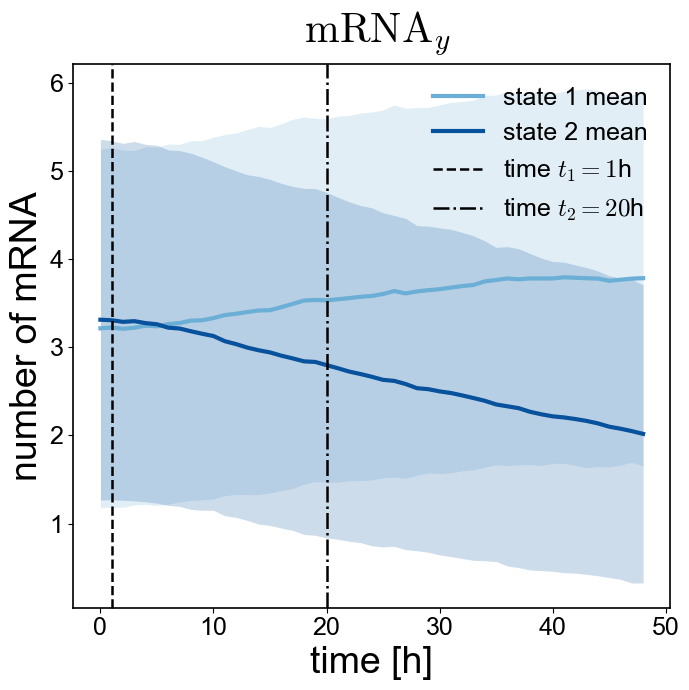

In [60]:
# %%
# === CONFIGURATION ===
twin_csv = Path("/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/drift_simulation/drift_simulation_0_15h/df_rows_0_0_1_14122025_221036_ncells_6000_2_states_2056f942.csv")
base_csv = Path("/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/drift_simulation/drift_simulation_0_15h/simulation_before_division_df_rows_0_0_1_14122025_221036_ncells_6000_2_states_2056f942.csv")

# %%
# === LOAD ===
df_base = pd.read_csv(base_csv)
df_rep = pd.read_csv(twin_csv)
print(f"✅ Loaded df_base ({len(df_base):,} rows)")
print(f"✅ Loaded df_rep  ({len(df_rep):,} rows)")

# Sanity check for state column
if "state" not in df_rep.columns:
    raise ValueError("No 'state' column found in df_rep — did you add it in process_param_set()?")

# Infer states for df_base if missing (optional)
if "state" not in df_base.columns:
    n_cells_half = df_rep["clone_id"].nunique() // 2
    df_base["state"] = ["up"] * n_cells_half + ["down"] * n_cells_half

# %%
# === DETECT GENES ===
mrna_cols = [c for c in df_rep.columns if c.endswith("_mRNA")]
protein_cols = [c for c in df_rep.columns if c.endswith("_protein")]
genes = sorted({c.split("_")[0] + "_" + c.split("_")[1] for c in protein_cols})
print(f"Detected genes: {genes}")

# === PLOT PARENT POPULATION (df_base) ===
gene_to_plot = "gene_1"

# %%
# === PLOT TWIN POPULATION (df_rep) ===
# plot_state_dynamics(df_rep, gene_to_plot, "mRNA", "Twin population")
# plot_state_dynamics(df_rep, gene_to_plot, "protein", "Twin population")

# === PLOT PARENT POPULATION (df_base) ===
gene_to_plot = "gene_2"

# %%
# === PLOT TWIN POPULATION (df_rep) ===
plot_state_dynamics(df_rep, gene_to_plot, "mRNA", "")
# plot_state_dynamics(df_rep, gene_to_plot, "protein", "Twin population")


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


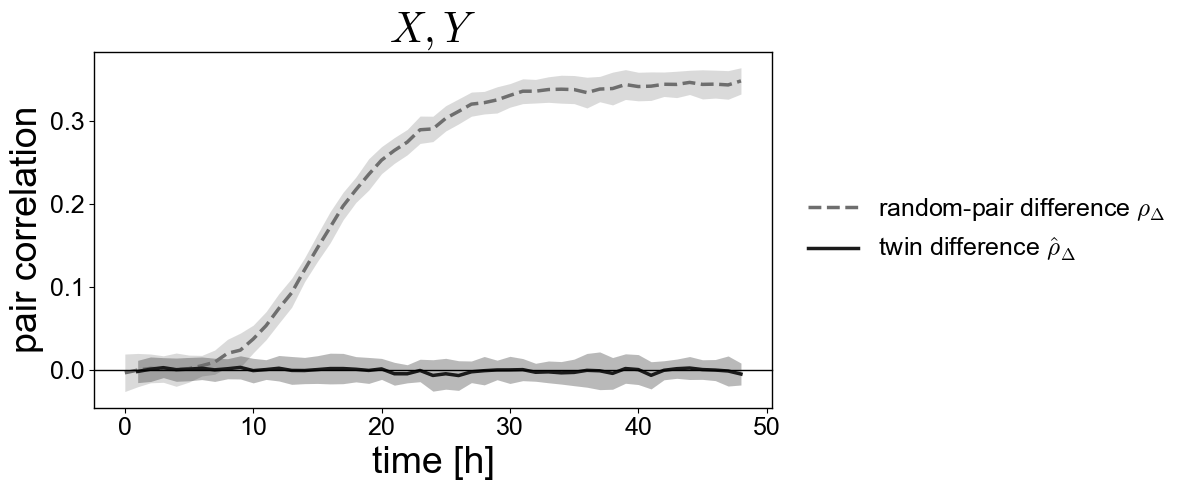

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


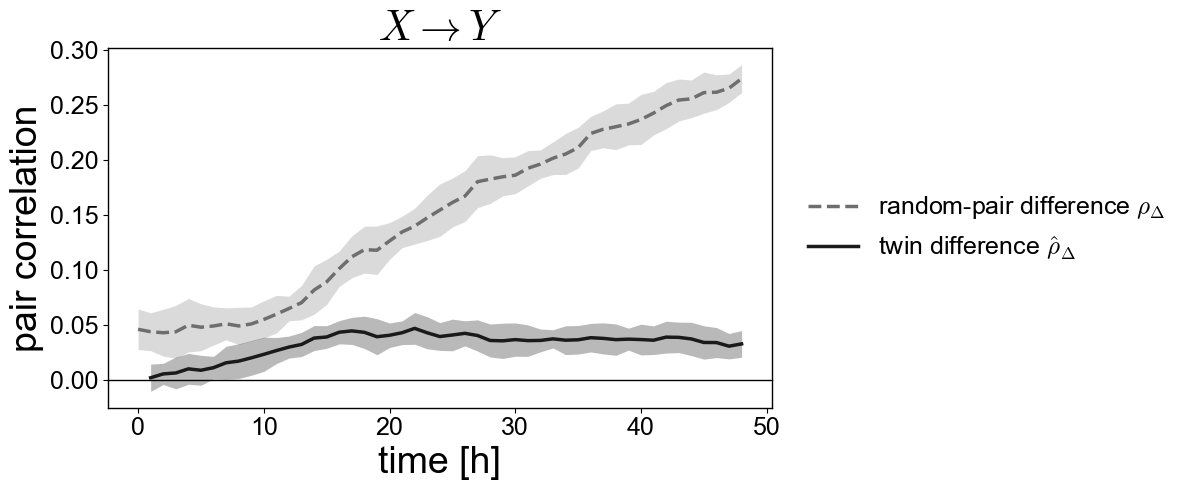

In [56]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm
import matplotlib.pyplot as plt

# ======================================================
# CONFIG
# ======================================================
DATA_FOLDER = Path(
    "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/"
    "drift_simulation/drift_simulation_0_15h"
)

GENE_A = "gene_1"
GENE_B = "gene_2"
KIND   = "mRNA"        # or "protein"

RANDOM_FRAC = 0.5
RANDOM_SEED = 42
MIN_PAIRS = 10

# ======================================================
# STYLE CONFIG - Three shades of grey
# ======================================================


# ======================================================
# LOW-LEVEL HELPERS
# ======================================================
def get_twin_pairs_by_time(df):
    """Return dict: time -> (rep0, rep1) for true twins."""
    out = {}
    for t, tdf in df.groupby("time_step"):
        twins = (
            tdf.groupby("clone_id")
               .filter(lambda x: len(x) == 2)
               .sort_values("clone_id")
        )
        if len(twins) == 0:
            continue

        rep0 = twins.groupby("clone_id").nth(0)
        rep1 = twins.groupby("clone_id").nth(1)
        out[t] = (rep0, rep1)
    return out


def get_random_pairs_by_time(df, frac=0.5, seed=42):
    """Return dict: time -> (rep0, rep1) for random pairs."""
    rng = np.random.default_rng(seed)
    out = {}

    for t, tdf in df.groupby("time_step"):
        shuffled = tdf.sample(frac=1, random_state=seed)
        n = int(len(shuffled) * frac)
        n = (n // 2) * 2  # even
        if n < 2:
            continue

        s = shuffled.iloc[:n]
        rep0 = s.iloc[::2]
        rep1 = s.iloc[1::2]
        out[t] = (rep0, rep1)

    return out


def spearman_safe(x, y):
    if len(x) < MIN_PAIRS:
        return np.nan
    return spearmanr(x, y).correlation

# ======================================================
# PROCESS ONE REPLICATE
# ======================================================
def process_replicate(df):
    """
    Compute ALL metrics for ONE replicate.
    Returns dict of DataFrames keyed by metric name.
    """
    colA = f"{GENE_A}_{KIND}"
    colB = f"{GENE_B}_{KIND}"

    records = {
        "delta_twin": [],
        "delta_rand": [],
        "gene": [],
        "gene_rand": [],
    }

    # --- Δ-based ---
    twin_pairs = get_twin_pairs_by_time(df)
    rand_pairs = get_random_pairs_by_time(df, RANDOM_FRAC, RANDOM_SEED)

    for t in sorted(set(twin_pairs) | set(rand_pairs)):
        # Δ twin
        if t in twin_pairs:
            r0, r1 = twin_pairs[t]
            dA = r0[colA].values - r1[colA].values
            dB = r0[colB].values - r1[colB].values
            records["delta_twin"].append((t, spearman_safe(dA, dB)))

        # Δ random
        if t in rand_pairs:
            r0, r1 = rand_pairs[t]
            dA = r0[colA].values - r1[colA].values
            dB = r0[colB].values - r1[colB].values
            records["delta_rand"].append((t, spearman_safe(dA, dB)))

    # --- Gene–gene (population) ---
    rng = np.random.default_rng(RANDOM_SEED)
    for t, tdf in df.groupby("time_step"):
        A = tdf[colA].values
        B = tdf[colB].values

        records["gene"].append((t, spearman_safe(A, B)))
        records["gene_rand"].append((t, spearman_safe(A, rng.permutation(B))))

    return {
        k: pd.DataFrame(v, columns=["time", "corr"]).dropna()
        for k, v in records.items()
    }

# ======================================================
# STREAMING AGGREGATION
# ======================================================
def stream_aggregate(files):
    acc = {
        "delta_twin": defaultdict(list),
        "delta_rand": defaultdict(list),
        "gene": defaultdict(list),
        "gene_rand": defaultdict(list),
    }

    for f in tqdm(files, desc="Streaming replicates"):
        df = pd.read_csv(f)

        result = process_replicate(df)

        for key, df_corr in result.items():
            for _, r in df_corr.iterrows():
                acc[key][r["time"]].append(r["corr"])

        del df  # free memory

    # convert to mean ± std
    out = {}
    for key, d in acc.items():
        times = sorted(d.keys())
        out[key] = pd.DataFrame({
            "time": times,
            "mean": [np.mean(d[t]) for t in times],
            "std":  [np.std(d[t])  for t in times],
        })

    return out

# ======================================================
# PLOTTING - ALL THREE IN ONE PLOT
# ======================================================
def plot_three_correlations(twin, random, gene, title):
    fig, ax = plt.subplots(figsize=(12, 5))
    
    # Illustrator-safe settings
    fig.patch.set_alpha(0)
    ax.set_facecolor("none")
    
    # Plot in order: lightest to darkest (so darkest is on top)
    
    # 1. Gene (lightest) - background
    # style = STYLE_CONFIG["gene"]
    # ax.fill_between(
    #     gene["time"],
    #     gene["mean"] - gene["std"],
    #     gene["mean"] + gene["std"],
    #     color=style["color"],
    #     alpha=style["alpha"],
    #     linewidth=0,
    #     clip_on=False,
    #     zorder=1
    # )
    # ax.plot(
    #     gene["time"], 
    #     gene["mean"], 
    #     color=style["color"],
    #     linestyle=style["ls"],
    #     linewidth=style["lw"],
    #     label=style["label"],
    #     clip_on=False,
    #     zorder=4
    # )
    
    # 2. Random (medium)
    style = STYLE_CONFIG["random"]
    ax.fill_between(
        random["time"],
        random["mean"] - random["std"],
        random["mean"] + random["std"],
        color=style["color"],
        alpha=style["alpha"],
        linewidth=0,
        clip_on=False,
        zorder=2
    )
    ax.plot(
        random["time"], 
        random["mean"], 
        color=style["color"],
        linestyle=style["ls"],
        linewidth=style["lw"],
        label=style["label"],
        clip_on=False,
        zorder=5
    )
    
    # 3. Twin (darkest) - foreground
    style = STYLE_CONFIG["twin"]
    ax.fill_between(
        twin["time"],
        twin["mean"] - twin["std"],
        twin["mean"] + twin["std"],
        color=style["color"],
        alpha=style["alpha"],
        linewidth=0,
        clip_on=False,
        zorder=3
    )
    ax.plot(
        twin["time"], 
        twin["mean"], 
        color=style["color"],
        linestyle=style["ls"],
        linewidth=style["lw"],
        label=style["label"],
        clip_on=False,
        zorder=6
    )

    ax.axhline(0, color="black", lw=1, clip_on=False, zorder=7)
    ax.set_xlabel("time [h]")
    ax.set_ylabel("pair correlation")
    ax.set_title(title)
    ax.legend(
    frameon=False,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
    )

    
    # Spine cleanup
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1)
        spine.set_clip_on(False)
    
    plt.tight_layout()
    
    # Create safe filename
    safe_title = title.replace('$', '').replace('\\', '').replace('rightarrow', 'to').replace(' ', '_')
    plt.savefig(
        f"/home/gzu5140/Keerthana_b1042/grnInference/plots/drift_simulation/{safe_title}.pdf",
        format="pdf",
        bbox_inches="tight",
        facecolor="none",
        edgecolor="none",
        transparent=True
    )
    plt.show()

STYLE_CONFIG = {
    "twin": {
        "color": "#1A1A1A",      # Darkest grey (most important)
        "ls": "-",               # Solid
        "lw": 2.5,
        "alpha": 0.30,
        "label": r"twin difference $\hat{\rho}_\Delta$"
    },
    "random": {
        "color": "#6E6E6E",      # Medium grey
        "ls": "--",              # Dashed
        "lw": 2.5,
        "alpha": 0.25,
        "label": r"random-pair difference $\rho_\Delta$"
    },
    "gene": {
        "color": "#CFCFCF",      # Lightest grey
        "ls": "-.",       # Custom dash (longer dashes)
        "lw": 2.5,
        "alpha": 0.25,
        "label": r"gene correlation $\rho$"
    }
}
# ======================================================
# RUN
# ======================================================
# no_reg_files = [f for f in DATA_FOLDER.glob("df*no_reg*.csv") if "30102025" not in f.name]
# if len(no_reg_files) > 20:
#     no_reg_files = no_reg_files[:20]
# reg_files    = [f for f in DATA_FOLDER.glob("df*.csv") if "no_reg" not in f.name and "30102025" not in f.name]
# if len(reg_files) > 20:
#     reg_files = reg_files[:20]

# no_reg = stream_aggregate(no_reg_files)
# reg    = stream_aggregate(reg_files)

# ---- FINAL PLOTS - ALL THREE CORRELATIONS ----

plot_three_correlations(
    no_reg["delta_twin"],
    no_reg["delta_rand"],
    no_reg["gene"],
    r"$X, Y$"
)

plot_three_correlations(
    reg["delta_twin"],
    reg["delta_rand"],
    reg["gene"],
    r"$X \rightarrow Y$"
)

In [47]:
dfs = []
for key, df in reg.items():
    tmp = df.copy()
    tmp["metric"] = key
    dfs.append(tmp)

reg_df = pd.concat(dfs, ignore_index=True)
reg_df.to_csv(f"{path_to_plot_data}/drift_sim/regulation_corr.csv")